In [2]:
import pandas as pd

# Download SimpleMaps free CSV
url = "https://simplemaps.com/static/data/world-cities/basic/simplemaps_worldcities_basicv1.77.zip"

# Or use geopandas with Natural Earth data
import geopandas as gpd
world = gpd.read_file(gpd.datasets.get_path('naturalearth_cities'))
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_cities' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

In [6]:
import geopandas as gpd

# Download directly from Natural Earth
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_populated_places.zip"
world = gpd.read_file(url)

# Filter for Europe
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]

# Keep useful columns
europe_df = europe[['NAME', 'geometry']].copy()
europe_df['lon'] = europe_df.geometry.x
europe_df['lat'] = europe_df.geometry.y

print(europe_df[['NAME', 'lat', 'lon']].head())

            NAME        lat        lon
0   Vatican City  41.903282  12.453387
1     San Marino  43.936096  12.441770
2          Vaduz  47.133724   9.516670
4     Luxembourg  49.611660   6.130003
10        Monaco  43.739646   7.406913


In [7]:
europe_df.shape

(55, 4)

### Increase resolution (:10milion)

In [8]:
import geopandas as gpd

# Use 10m scale instead of 110m — way more cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
world = gpd.read_file(url)

# Filter for Europe
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]

# Keep useful columns
europe_df = europe[['NAME', 'ADM0NAME', 'POP_MAX', 'geometry']].copy()
europe_df['lon'] = europe_df.geometry.x
europe_df['lat'] = europe_df.geometry.y
europe_df = europe_df.drop(columns='geometry')

# Optional: sort by population
europe_df = europe_df.sort_values('POP_MAX', ascending=False)

print(f"Total cities: {len(europe_df)}")
print(europe_df.head(10))

# Save to CSV
europe_df.to_csv("europe_cities.csv", index=False)

Total cities: 1148
                 NAME        ADM0NAME   POP_MAX        lon        lat
7266           Moscow          Russia  10452000  37.613577  55.754110
7263         Istanbul          Turkey  10061000  28.974277  41.017602
7278            Paris          France   9904000   2.352992  48.858092
7262           London  United Kingdom   8567000  -0.118668  51.501941
7229           Madrid           Spain   5567000  -3.685297  40.401972
7122        Barcelona           Spain   4920000   2.181424  41.385245
7135  St.  Petersburg          Russia   4553000  30.314074  59.940960
7119           Ankara          Turkey   3716000  32.862446  39.929184
7241           Berlin         Germany   3406000  13.399603  52.523764
7215          Algiers         Algeria   3354000   3.048607  36.765011


## Birds

In [12]:

df_native = pd.read_csv(r"C:\Users\user\Downloads\native_species_europe_only_cleaned.csv")
df_migratory = pd.read_csv(r"C:\Users\user\Downloads\migra_species_europe_only_cleaned.csv")

C:\Users\user\AppData\Local\Temp\ipykernel_46824\3779601395.py:1: DtypeWarning: Columns (0: COUNTY, 1: COUNTY CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_native = pd.read_csv(r"C:\Users\user\Downloads\native_species_europe_only_cleaned.csv")


In [13]:
df_native

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,...,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,obsDt,year,month,day_of_week,day_of_year,howMany
0,Great Spotted Woodpecker,Dendrocopos major,1.0,NaN,Portugal,PT,Portalegre,PT-12,Castelo de Vide,PT-12-CV,...,2018-01-26,obsr429991,S42251764,Stationary,2018-01-26,2018,1,4,26,1.0
1,Great Spotted Woodpecker,Dendrocopos major,1.0,NaN,Ukraine,UA,Kirovohrads'ka Oblast',UA-35,NaN,NaN,...,2018-12-22,obsr1017757,S50893829,Traveling,2018-12-22,2018,12,5,356,1.0
2,Great Spotted Woodpecker,Dendrocopos major,3.0,NaN,Spain,ES,"Madrid, Comunidad de",ES-MD,NaN,NaN,...,2018-01-21,obsr771146,S42131687,Traveling,2018-01-21,2018,1,6,21,3.0
3,Great Spotted Woodpecker,Dendrocopos major,5.0,NaN,Croatia,HR,Koprivnicko-kriÅ¾evacka Å¾upanija,HR-06,NaN,NaN,...,2018-01-06,obsr733488,S41672345,Traveling,2018-01-06,2018,1,5,6,5.0
4,Great Spotted Woodpecker,Dendrocopos major,2.0,NaN,United Kingdom,GB,Scotland,GB-SCT,Fife,GB-SCT-FIF,...,2018-06-09,obsr407628,S46534187,Traveling,2018-06-09,2018,6,5,160,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4024140,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,...,2022-04-09,obsr644609,S106631527,Stationary,2022-04-09,2022,4,5,99,1.0
4024141,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,...,2022-05-05,obsr112798,S108980796,Traveling,2022-05-05,2022,5,3,125,1.0
4024142,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,...,2022-10-07,obsr1771248,S120180143,Incidental,2022-10-07,2022,10,4,280,1.0
4024143,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,...,2022-12-12,obsr988333,S123861665,Stationary,2022-12-12,2022,12,0,346,1.0


In [14]:
df_migratory

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,...,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,obsDt,year,month,day_of_week,day_of_year,howMany
0,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,CÃ¡diz,ES-AN-CD,...,2017-01-20,obsr756857,S33804365,Traveling,2017-01-20,2017,1,4,20,2.0
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,...,2017-01-16,obsr271019,S33940654,Traveling,2017-01-16,2017,1,0,16,2.0
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,...,2017-01-16,obsr427437,S33751745,Traveling,2017-01-16,2017,1,0,16,2.0
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,...,2017-01-16,obsr546444,S34018122,Traveling,2017-01-16,2017,1,0,16,2.0
4,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,...,2017-01-21,obsr777138,S33908528,Traveling,2017-01-21,2017,1,5,21,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863367,Black Tern,Chlidonias niger,1.0,NaN,Netherlands,NL,Zuid-Holland,NL-ZH,NaN,NaN,...,2025-09-16,obsr1478235,S273768812,Stationary,2025-09-16,2025,9,1,259,1.0
863368,Black Tern,Chlidonias niger,1.0,NaN,Poland,PL,Kujawsko-pomorskie,PL-KP,NaN,NaN,...,2025-09-19,obsr511948,S274163270,Stationary,2025-09-19,2025,9,4,262,1.0
863369,Black Tern,Chlidonias niger,1.0,NaN,United Kingdom,GB,England,GB-ENG,Merseyside,GB-ENG-KWL,...,2025-10-05,obsr3384199,S277528628,Traveling,2025-10-05,2025,10,6,278,1.0
863370,Black Tern,Chlidonias niger,1.0,NaN,Ireland,IE,Connaught,IE-C,Mayo,IE-C-MO,...,2025-10-09,obsr685602,S278224399,Traveling,2025-10-09,2025,10,3,282,1.0


## Best option

In [10]:
import geopandas
# Load European cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
import geopandas as gpd
world = gpd.read_file(url)
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]
cities = europe[['NAME', 'ADM0NAME', 'geometry']].copy()
cities['lon'] = cities.geometry.x
cities['lat'] = cities.geometry.y
cities = cities.drop(columns='geometry').reset_index(drop=True)
cities

,NAME,ADM0NAME,lon,lat
0,L'Ariana,Tunisia,10.199998,36.866673
1,Jendouba,Tunisia,8.749999,36.500004
2,Kasserine,Tunisia,8.716698,35.216703
3,Sdid Bouzid,Tunisia,9.500004,35.016696
4,Siliana,Tunisia,9.383302,36.083304
...,...,...,...,...
1143,London,United Kingdom,-0.118668,51.501941
1144,Istanbul,Turkey,28.974277,41.017602
1145,Moscow,Russia,37.613577,55.754110
1146,Rome,Italy,12.481313,41.897902


## Native

In [15]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# build KD-Tree on city coordinates ---
# convert lat/lon to radians for accurate distance calculation
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# find closest city for each bird observation ---
birds_rad = np.radians(df_native[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# convert distance from radians to kilometers (Earth radius = 6371 km)
df_native['closest_city'] = cities['NAME'].iloc[indices].values
df_native['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_native['distance_km'] = np.round(distances * 6371, 2)

df_native

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,...,OBSERVATION TYPE,obsDt,year,month,day_of_week,day_of_year,howMany,closest_city,closest_city_country,distance_km
0,Great Spotted Woodpecker,Dendrocopos major,1.0,NaN,Portugal,PT,Portalegre,PT-12,Castelo de Vide,PT-12-CV,...,Stationary,2018-01-26,2018,1,4,26,1.0,Portalegre,Portugal,21.48
1,Great Spotted Woodpecker,Dendrocopos major,1.0,NaN,Ukraine,UA,Kirovohrads'ka Oblast',UA-35,NaN,NaN,...,Traveling,2018-12-22,2018,12,5,356,1.0,Kremenchuk,Ukraine,24.04
2,Great Spotted Woodpecker,Dendrocopos major,3.0,NaN,Spain,ES,"Madrid, Comunidad de",ES-MD,NaN,NaN,...,Traveling,2018-01-21,2018,1,6,21,3.0,Madrid,Spain,15.05
3,Great Spotted Woodpecker,Dendrocopos major,5.0,NaN,Croatia,HR,Koprivnicko-kriÅ¾evacka Å¾upanija,HR-06,NaN,NaN,...,Traveling,2018-01-06,2018,1,5,6,5.0,Zagreb,Croatia,70.12
4,Great Spotted Woodpecker,Dendrocopos major,2.0,NaN,United Kingdom,GB,Scotland,GB-SCT,Fife,GB-SCT-FIF,...,Traveling,2018-06-09,2018,6,5,160,2.0,Dundee,United Kingdom,43.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4024140,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,...,Stationary,2022-04-09,2022,4,5,99,1.0,Vatican City,Vatican,0.36
4024141,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,...,Traveling,2022-05-05,2022,5,3,125,1.0,Vatican City,Vatican,0.36
4024142,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,...,Incidental,2022-10-07,2022,10,4,280,1.0,Vatican City,Vatican,0.36
4024143,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,...,Stationary,2022-12-12,2022,12,0,346,1.0,Vatican City,Vatican,0.36


In [16]:
df_native.columns

Index(['COMMON NAME', 'SCIENTIFIC NAME', 'OBSERVATION COUNT', 'AGE/SEX',
       'COUNTRY', 'COUNTRY CODE', 'STATE', 'STATE CODE', 'COUNTY',
       'COUNTY CODE', 'ATLAS BLOCK', 'LOCALITY', 'LOCALITY ID',
       'LOCALITY TYPE', 'LATITUDE', 'LONGITUDE', 'OBSERVATION DATE',
       'OBSERVER ID', 'SAMPLING EVENT IDENTIFIER', 'OBSERVATION TYPE', 'obsDt',
       'year', 'month', 'day_of_week', 'day_of_year', 'howMany',
       'closest_city', 'closest_city_country', 'distance_km'],
      dtype='str')

In [17]:
df_native["COMMON NAME"].unique()

<StringArray>
['Great Spotted Woodpecker',                'Tawny Owl',
                'Great Tit',          'Green Sandpiper',
       'Eurasian Bullfinch',           'European Robin']
Length: 6, dtype: str

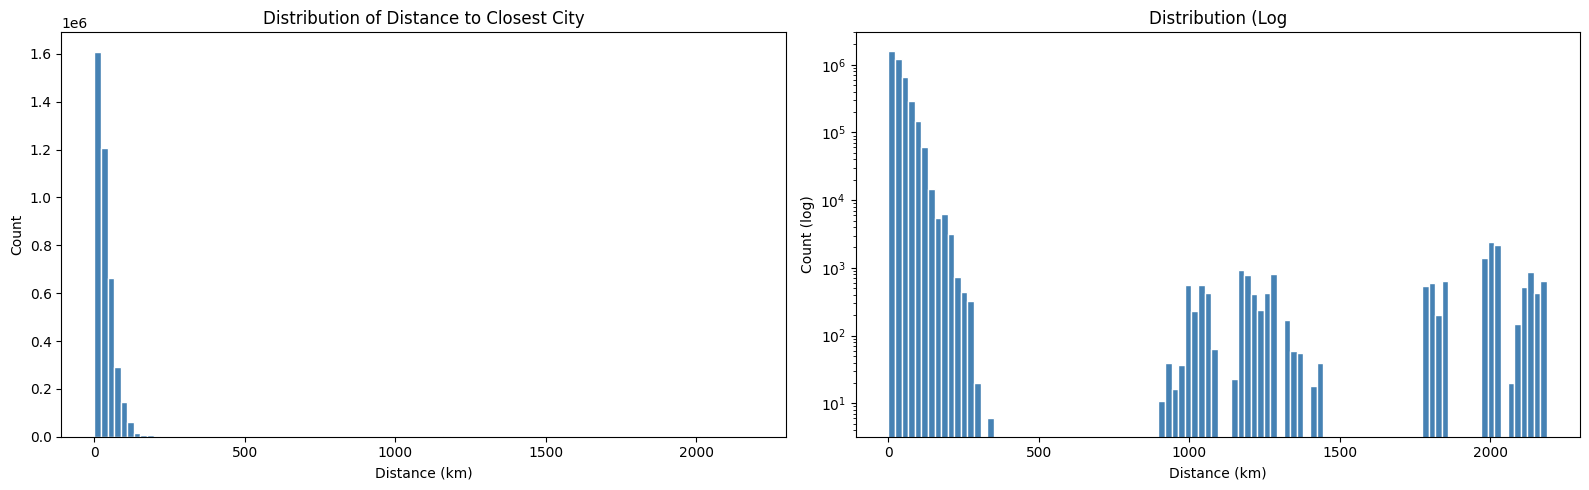

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_native['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_native['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

In [19]:
print(df_native['distance_km'].describe())
print(f"\nMedian:  {df_native['distance_km'].median():.2f} km")
print(f"Skewness: {df_native['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_native['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_native['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_native['distance_km'] <= 100).mean()*100:.1f}%")

count    4.024145e+06
mean     4.176515e+01
std      1.133242e+02
min      2.000000e-02
25%      1.320000e+01
50%      2.829000e+01
75%      4.897000e+01
max      2.188640e+03
Name: distance_km, dtype: float64

Median:  28.29 km
Skewness: 15.16
% within 10km:  18.2%
% within 50km:  75.9%
% within 100km: 95.9%


In [20]:
# check what's driving the outliers
outliers = df_native[df_native['distance_km'] > 500]
print(outliers['COUNTRY CODE'].value_counts())
print(outliers[['LATITUDE', 'LONGITUDE', 'COUNTRY CODE', 'distance_km']].head(20))

COUNTRY CODE
PT    11392
ES     5084
Name: count, dtype: int64
       LATITUDE  LONGITUDE COUNTRY CODE  distance_km
68    27.988852 -15.593290           ES      1182.65
130   28.160268 -16.642399           ES      1270.53
394   28.190192 -16.665776           ES      1271.06
716   28.190192 -16.665776           ES      1271.06
867   27.961783 -15.619554           ES      1186.77
870   28.190192 -16.665776           ES      1271.06
1236  28.165900 -16.638700           ES      1269.85
1563  28.006094 -15.599630           ES      1182.15
1581  28.190192 -16.665776           ES      1271.06
1584  28.026758 -15.612892           ES      1182.07
1700  28.257575 -16.769551           ES      1277.21
1933  28.190192 -16.665776           ES      1271.06
2217  28.155805 -16.637995           ES      1270.36
2605  27.951713 -15.651890           ES      1190.36
2883  28.165900 -16.638700           ES      1269.85
3497  28.190192 -16.665776           ES      1271.06
3653  27.965669 -15.595093          

## Migratory

In [43]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# build KD-Tree on city coordinates ---
# convert lat/lon to radians for accurate distance calculation
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# find closest city for each bird observation ---
birds_rad = np.radians(df_migratory[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# convert distance from radians to kilometers (Earth radius = 6371 km)
df_migratory['closest_city'] = cities['NAME'].iloc[indices].values
df_migratory['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_migratory['distance_km'] = np.round(distances * 6371, 2)

df_migratory.columns

Index(['COMMON NAME', 'SCIENTIFIC NAME', 'OBSERVATION COUNT', 'AGE/SEX',
       'COUNTRY', 'COUNTRY CODE', 'STATE', 'STATE CODE', 'COUNTY',
       'COUNTY CODE', 'ATLAS BLOCK', 'LOCALITY', 'LOCALITY ID',
       'LOCALITY TYPE', 'LATITUDE', 'LONGITUDE', 'OBSERVATION DATE',
       'OBSERVER ID', 'SAMPLING EVENT IDENTIFIER', 'OBSERVATION TYPE', 'obsDt',
       'year', 'month', 'day_of_week', 'day_of_year', 'howMany',
       'closest_city', 'closest_city_country', 'distance_km'],
      dtype='str')

In [22]:
df_migratory["COMMON NAME"].unique()

<StringArray>
[     'Eurasian Whimbrel',       'Curlew Sandpiper',             'Sanderling',
           'Little Stint',               'Red Knot',                   'Ruff',
        'Green Sandpiper',         'Wood Sandpiper',               'Garganey',
 'European Honey-buzzard',             'Black Tern']
Length: 11, dtype: str

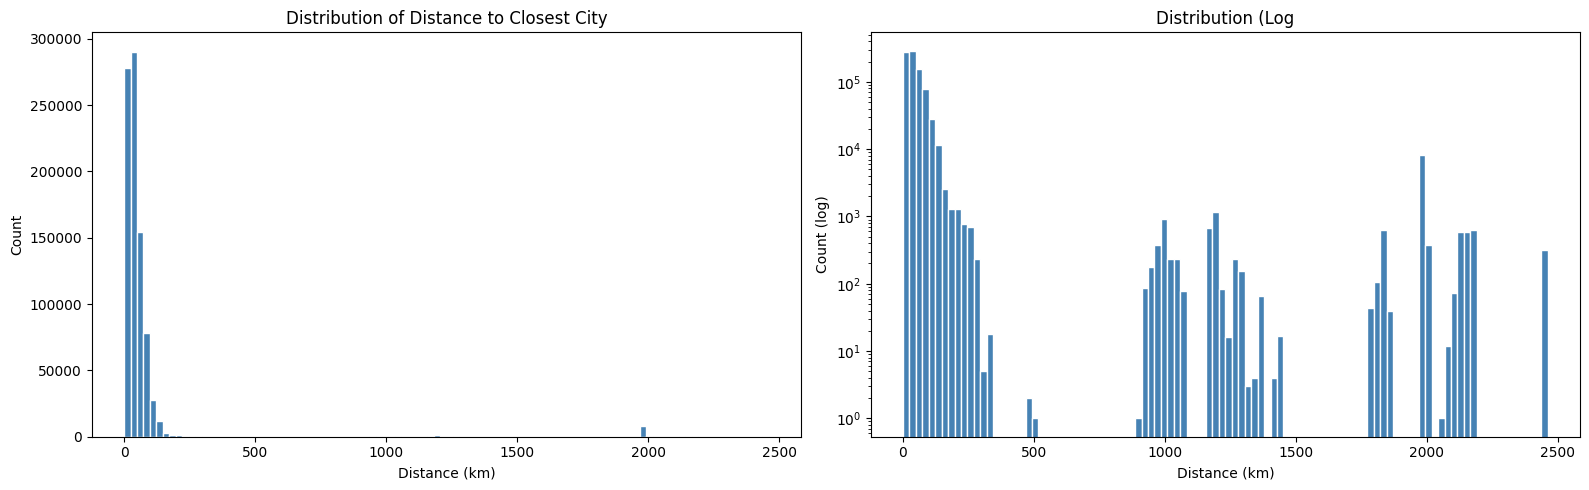

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

In [24]:
print(df_migratory['distance_km'].describe())
print(f"\nMedian:  {df_migratory['distance_km'].median():.2f} km")
print(f"Skewness: {df_migratory['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_migratory['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_migratory['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_migratory['distance_km'] <= 100).mean()*100:.1f}%")

count    863372.000000
mean         75.120181
std         242.817631
min           0.060000
25%          20.760000
50%          35.700000
75%          58.920000
max        2460.870000
Name: distance_km, dtype: float64

Median:  35.70 km
Skewness: 7.41
% within 10km:  8.5%
% within 50km:  66.7%
% within 100km: 92.9%


In [25]:
# check what's driving the outliers
outliers = df_migratory[df_migratory['distance_km'] > 500]
print(outliers['COUNTRY CODE'].value_counts())
print(outliers[['LATITUDE', 'LONGITUDE', 'COUNTRY CODE', 'distance_km']].head(20))

COUNTRY CODE
PT    11871
ES     4365
Name: count, dtype: int64
     LATITUDE  LONGITUDE COUNTRY CODE  distance_km
4   28.367192 -13.869656           ES      1003.72
5   28.367192 -13.869656           ES      1003.72
16  38.524264 -28.628097           PT      2166.33
17  38.393810 -28.254347           PT      2124.98
18  38.393810 -28.254347           PT      2124.98
19  38.393810 -28.254347           PT      2124.98
20  38.393810 -28.254347           PT      2124.98
21  38.393810 -28.254347           PT      2124.98
22  38.393810 -28.254347           PT      2124.98
23  38.535062 -28.530885           PT      2155.51
24  38.706343 -27.047567           PT      1990.47
25  38.706343 -27.047567           PT      1990.47
26  32.742671 -16.701794           PT      1031.21
27  32.742671 -16.701794           PT      1031.21
32  28.375467 -16.864716           ES      1279.89
36  38.522603 -28.668768           PT      2170.86
37  38.522603 -28.668768           PT      2170.86
38  38.706343 -27.0

In [26]:
df_migratory["closest_city"].unique()

<StringArray>
[    'Algeciras',        'Huelva',         'Rabat',          'Cork',
          'Faro',        'Lisbon',      'Portimão',         'Cádiz',
     'Santander', 'San Sebastián',
 ...
         'Stans',        'Përmet',     'Çanakkale',        'Tetovo',
     'Târgu Jiu',     'Baia Mare',      'Bistrița',  'Piatra-Neamt',
      'Pristina',         'Krujë']
Length: 803, dtype: str

In [27]:
all_the_cities = set(list(df_native["closest_city"].unique())).union(list(df_migratory["closest_city"].unique()))


In [28]:
len(all_the_cities)


818

In [29]:
df_cities_from_air_pollution = pd.read_csv("air_pollution_final.csv")

In [30]:
df_cities_from_air_pollution.head()

,Unnamed: 0,Country,City,Year,co,no2,o3,pm10,pm25,so2
0,0,AT,Graz,2016,0.1,15.433333,NaN,21.666667,NaN,1.600000
1,1,AT,Graz,2017,0.1,12.301093,NaN,22.535519,NaN,1.426230
2,2,AT,Graz,2018,0.1,10.634973,NaN,20.196721,NaN,1.283607
3,3,AT,Graz,2019,0.1,9.852139,NaN,16.844920,NaN,1.137265
4,4,AT,Graz,2020,0.1,8.792405,NaN,17.083544,NaN,1.022785


In [ ]:
df_cities_from_air_pollution["pm25"].isna()

In [35]:
# Convert columns to sets
bird_cities = all_the_cities
pollution_cities = set(df_cities_from_air_pollution["City"])

# Find the overlap (Intersection)
common_cities = bird_cities.intersection(pollution_cities)

# Check if pollution_cities is a subset
is_subset = pollution_cities.issubset(bird_cities)

print(f"Number of common cities: {len(common_cities)}")
print(f"Are all 240 cities in the bird data? {is_subset}")

# See which ones are missing
missing_from_birds = pollution_cities - bird_cities
print(f"Cities in pollution data but not in bird data: {len(missing_from_birds)} , {missing_from_birds}")

Number of common cities: 176
Are all 240 cities in the bird data? False
Cities in pollution data but not in bird data: 64 , {'Płock', 'Granada', 'Timişoara', 'Nijmegen', 'Kamianske', 'Iaşi', 'Newport', 'Vantaa', 'İzmir', 'Hannover', 'Erzurum', 'Balıkesir', 'Santa Cruz de Tenerife', 'Trabzon', 'Donostia / San Sebastián', 'Darmstadt', 'Galaţi', 'Pilsen', 'Las Palmas de Gran Canaria', 'Sivas', 'Eskişehir', 'Thessaloníki', 'Tarnów', 'Antakya', 'Gasteiz / Vitoria', 'Breda', 'Kayseri', 'Castelló de la Plana', 'Zabrze', 'Ploieşti', 'Konya', 'Funchal', 'Piteşti', 'Braşov', 'Adana', 'Ankara', 'Istanbul', 'Samsun', 'Bursa', 'Kütahya', 'Novosibirsk', 'Sevilla', 'Constanţa', 'Krasnoyarsk', 'Saint Petersburg', 'Prato', 'Zaporizhia', 'Denizli', 'Dordrecht', 'Brescia', 'Rybnik', 'Kryvyi Rih', 'Chelyabinsk', 'Moscow', 'İzmit', 'Adapazarı', 'Copenhagen', 'Tbilisi', 'Limassol', 'Tomsk', 'Preston', 'Köln', 'Râmnicu Vâlcea', 'Nizhniy Novgorod'}


In [ ]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="bird_pollution_project")


city_coords = {}

for city in pollution_cities:
    try:
        
        location = geolocator.geocode(city)
        if location:
            city_coords[city] = (location.latitude, location.longitude)
        time.sleep(1) # Respect API limits (1 request per second)
    except:
        continue

# Map these back to your pollution DataFrame


NameError: name 'df_pollution' is not defined

In [37]:
df_cities_from_air_pollution['lat'] = df_cities_from_air_pollution['City'].map(lambda x: city_coords.get(x, (None, None))[0])
df_cities_from_air_pollution['lon'] = df_cities_from_air_pollution['City'].map(lambda x: city_coords.get(x, (None, None))[1])

In [39]:
df_cities_from_air_pollution.to_csv("df_cities_from_air_pollution_with_coordinates.csv")

In [40]:
df_cities_from_air_pollution


,Unnamed: 0,Country,City,Year,co,no2,o3,pm10,pm25,so2,lat,lon
0,0,AT,Graz,2016,0.100000,15.433333,NaN,21.666667,NaN,1.600000,47.070868,15.438279
1,1,AT,Graz,2017,0.100000,12.301093,NaN,22.535519,NaN,1.426230,47.070868,15.438279
2,2,AT,Graz,2018,0.100000,10.634973,NaN,20.196721,NaN,1.283607,47.070868,15.438279
3,3,AT,Graz,2019,0.100000,9.852139,NaN,16.844920,NaN,1.137265,47.070868,15.438279
4,4,AT,Graz,2020,0.100000,8.792405,NaN,17.083544,NaN,1.022785,47.070868,15.438279
...,...,...,...,...,...,...,...,...,...,...,...,...
1778,1778,XK,Pristina,2019,21.303030,15.896970,7.569697,23.590909,66.294118,5.493939,42.663877,21.164085
1779,1779,XK,Pristina,2020,14.248580,10.033123,20.845741,25.012618,69.580808,5.608517,42.663877,21.164085
1780,1780,XK,Pristina,2021,13.878548,8.859076,15.400000,21.219595,67.012887,3.714384,42.663877,21.164085
1781,1781,XK,Pristina,2022,10.293085,9.528319,14.291705,16.366071,70.554422,6.110360,42.663877,21.164085


In [ ]:
import geopandas as gpd
import pandas as pd

# 1. Create the Pollution GeoDataFrame
gdf_pollution = gpd.GeoDataFrame(
    df_cities_from_air_pollution, 
    geometry=gpd.points_from_xy(df_cities_from_air_pollution.lon, df_cities_from_air_pollution.lat),
    crs="EPSG:4326"
)

# 2. Create and Label the Bird GeoDataFrames
gdf_migratory = gpd.GeoDataFrame(
    df_migratory, 
    geometry=gpd.points_from_xy(df_migratory.LONGITUDE, df_migratory.LATITUDE),
    crs="EPSG:4326"
)
gdf_migratory['bird_type'] = 'Migratory'

gdf_native = gpd.GeoDataFrame(
    df_native, 
    geometry=gpd.points_from_xy(df_native.LONGITUDE, df_native.LATITUDE),
    crs="EPSG:4326"
)
gdf_native['bird_type'] = 'Native'

# 3. COMBINE them FIRST so the loop has all the data
gdf_birds_all = pd.concat([gdf_migratory, gdf_native], ignore_index=True)

# 4. Convert to a projected CRS (meters) for accurate distance calculation
# EPSG:3857 is great for general distance matching
gdf_birds_all_m = gdf_birds_all.to_crs(epsg=3857)
gdf_pollution_m = gdf_pollution.to_crs(epsg=3857)

final_list = []



KeyError: 'year'

In [46]:
# 5. Loop through the combined data by Year
for year in gdf_birds_all_m['year'].unique():
    birds_year = gdf_birds_all_m[gdf_birds_all_m['year'] == year]
    pollution_year = gdf_pollution_m[gdf_pollution_m['Year'] == year]
    
    if not pollution_year.empty:
        # Spatial join: finds the closest pollution point for every bird point in THAT year
        joined = gpd.sjoin_nearest(
            birds_year, 
            pollution_year, 
            how='left', 
            distance_col="dist_meters"
        )
        final_list.append(joined)

# 6. Create the final Analysis DataFrame
full_analysis_df = pd.concat(final_list, ignore_index=True)

# Convert distance to km for easier threshold filtering
full_analysis_df['dist_km'] = full_analysis_df['dist_meters'] / 1000

In [51]:
full_analysis_df

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,...,co,no2,o3,pm10,pm25,so2,lat,lon,dist_meters,dist_km
0,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,CÃ¡diz,ES-AN-CD,...,4.1,5.100000,32.500000,NaN,NaN,NaN,36.721303,-4.421637,165618.709003,165.618709
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,...,5.1,10.600000,10.200000,28.000000,NaN,2.100000,37.257587,-6.948494,9477.477578,9.477478
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,...,5.1,10.600000,10.200000,28.000000,NaN,2.100000,37.257587,-6.948494,9477.477578,9.477478
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,...,5.1,10.600000,10.200000,28.000000,NaN,2.100000,37.257587,-6.948494,9477.477578,9.477478
4,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,...,NaN,3.818354,28.922293,23.316456,39.588608,2.682278,28.128869,-15.434902,176825.915818,176.825916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4481691,Eurasian Bullfinch,Pyrrhula pyrrhula,1.0,NaN,Czech Republic,CZ,HlavnÃ­ mÄsto Praha,CZ-PR,NaN,NaN,...,NaN,7.500000,15.500000,18.000000,50.000000,0.700000,50.085011,14.426517,9668.242320,9.668242
4481692,Eurasian Bullfinch,Pyrrhula pyrrhula,1.0,NaN,United Kingdom,GB,England,GB-ENG,Suffolk,GB-ENG-SFK,...,NaN,1.900000,28.700000,12.000000,28.000000,NaN,52.628558,1.292395,93603.389953,93.603390
4481693,Eurasian Bullfinch,Pyrrhula pyrrhula,3.0,NaN,Slovenia,SI,Novo Mesto (urbane commune),SI-085,NaN,NaN,...,NaN,5.900000,16.500000,18.000000,56.000000,1.300000,45.813097,15.977279,95220.365778,95.220366
4481694,Eurasian Bullfinch,Pyrrhula pyrrhula,2.0,NaN,Portugal,PT,Viana do Castelo,PT-16,Caminha,PT-16-CA,...,NaN,0.500000,27.300000,15.000000,34.000000,2.600000,40.965157,-5.664018,375006.014966,375.006015


In [54]:
full_analysis_df["geometry"]

0           POINT (-624591.032 4300802.137)
1           POINT (-772986.169 4465608.844)
2           POINT (-772986.169 4465608.844)
3           POINT (-772986.169 4465608.844)
4          POINT (-1543963.043 3295347.686)
                         ...               
4481691     POINT (1599874.772 6453492.309)
4481692       POINT (71201.093 6855584.521)
4481693     POINT (1683390.038 5748148.109)
4481694      POINT (-979383.37 5144756.636)
4481695     POINT (2685126.562 8472968.471)
Name: geometry, Length: 4481696, dtype: geometry

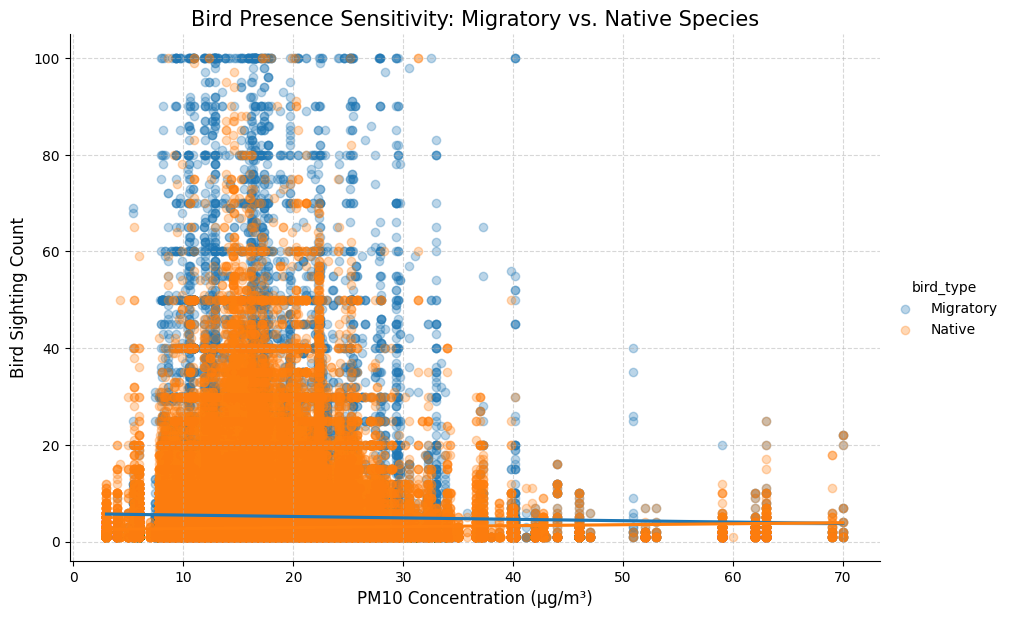

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

#  Filtering for a reasonable distance (within 25km of a station)
analysis_ready = full_analysis_df[full_analysis_df['dist_km'] <= 25].copy()

# Create the plot
g = sns.lmplot(
    data=analysis_ready, 
    x='pm10', 
    y='OBSERVATION COUNT', 
    hue='bird_type', 
    palette={'Migratory': '#1f77b4', 'Native': '#ff7f0e'}, # Blue and Orange
    scatter_kws={'alpha': 0.3}, # Make dots transparent to see overlaps
    height=6, 
    aspect=1.5
)

# Improve labels and title
plt.title('Bird Presence Sensitivity: Migratory vs. Native Species', fontsize=15)
plt.xlabel('PM10 Concentration (µg/m³)', fontsize=12)
plt.ylabel('Bird Sighting Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
#full_analysis_df.to_csv(r"C:\Users\user\Downloads\full_analysis_df.csv")